# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Iman Rasyid Sayuti
- **Email:** CDCC326D6Y1016@student.devacademy.id
- **ID Dicoding:** CDCC326D6Y1016

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda selama periode tahun 2011–2012?
- **Pertanyaan 2:** Pada jam berapa terjadi peningkatan jumlah penyewaan sepeda tertinggi pada hari kerja dibandingkan hari libur selama periode tahun 2011–2012?
- ...

## Import Semua Packages/Library yang Digunakan

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load df ...

In [18]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')


print(day_df.head())
print(hour_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

**Insight:** (Opsional)
- Dataset `day.csv` berisi data penyewaan sepeda harian selama tahun 2011–2012.
- Dataset `hour.csv` berisi data penyewaan sepeda per jam yang dapat digunakan untuk menganalisis pola penggunaan sepeda berdasarkan waktu.

### Assessing Data

#### Identifying ... problem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns

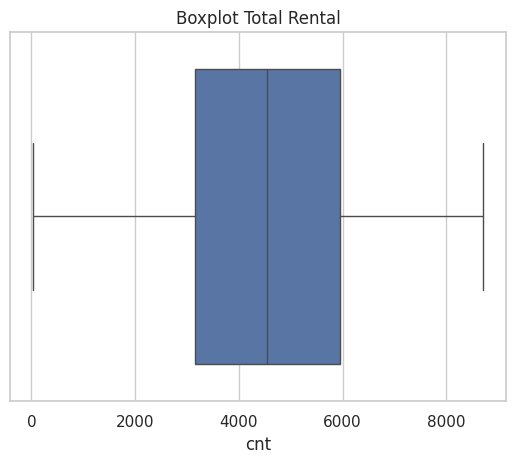

In [19]:
print(day_df.info())
print(hour_df.info())

print(day_df.isna().sum())
print(hour_df.isna().sum())

print(day_df.duplicated().sum())
print(hour_df.duplicated().sum())

print(day_df.describe())
print(hour_df.describe())

sns.boxplot(x=day_df['cnt'])
plt.title('Boxplot Total Rental')
plt.show()

**Steps to Take:**
- Mengecek Informasi Dataset
- Mengecek Missing Value
- Mengecek Duplicate Data
- Mengecek Statistik Deskriptif
- Mengecek Outlier

**Insight:** (Opsional)
- Tipe data tanggal masih object
- Nama kategori belum informatif

### Cleaning Data

#### Fixing ... problem

In [20]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

print(day_df.head())
print(hour_df.head())

   instant     dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1 2011-01-01  Spring   0     1        0        6           0   
1        2 2011-01-02  Spring   0     1        0        0           0   
2        3 2011-01-03  Spring   0     1        0        1           1   
3        4 2011-01-04  Spring   0     1        0        2           1   
4        5 2011-01-05  Spring   0     1        0        3           1   

  weathersit      temp     atemp       hum  windspeed  casual  registered  \
0       Mist  0.344167  0.363625  0.805833   0.160446     331         654   
1       Mist  0.363478  0.353739  0.696087   0.248539     131         670   
2      Clear  0.196364  0.189405  0.437273   0.248309     120        1229   
3      Clear  0.200000  0.212122  0.590435   0.160296     108        1454   
4      Clear  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant     dteday  season  yr  mnt

**Insight:** (Opsional)
- Kolom tanggal berhasil diubah menjadi format datetime sehingga lebih mudah dianalisis.
- Nilai kategori numerik seperti season dan weathersit berhasil diubah menjadi label yang lebih mudah dipahami.

## Exploratory Data Analysis (EDA)

### Explore ...

In [21]:
day_df.head()

day_df.groupby(by="season").cnt.mean().sort_values(ascending=False)

day_df.groupby(by="weathersit").cnt.mean().sort_values(ascending=False)

day_df.groupby(by="workingday").cnt.mean()



weather_rentals = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

print(weather_rentals)

hourly_rentals = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

print(hourly_rentals.head())

weathersit
Clear              4876.786177
Mist               4035.862348
Light Snow/Rain    1803.285714
Name: cnt, dtype: float64
   hr  workingday        cnt
0   0           0  90.800000
1   0           1  36.786290
2   1           0  69.508696
3   1           1  16.552632
4   2           0  53.171053


**Insight:** (Opsional)
-Dataset memiliki 16 kolom dan berisi informasi terkait cuaca, musim, hari kerja, dan jumlah rental sepeda.
- Kondisi cuaca cerah memiliki rata-rata jumlah rental tertinggi dibandingkan kondisi cuaca lainnya.
- Hari kerja menunjukkan pola penggunaan sepeda yang lebih tinggi pada jam sibuk.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

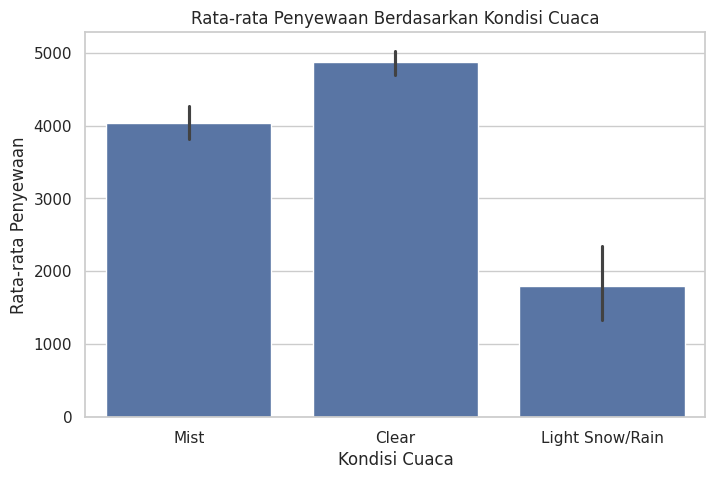

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=day_df,
    x='weathersit',
    y='cnt',
    estimator=np.mean
)

plt.title('Rata-rata Penyewaan Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Pertanyaan 2:

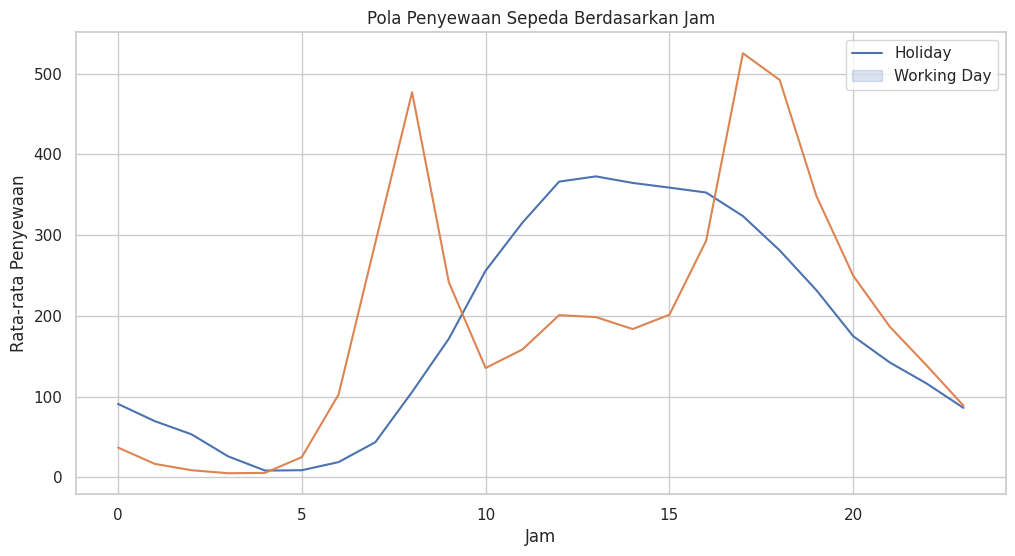

In [23]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_rentals,
    x='hr',
    y='cnt',
    hue='workingday'
)

plt.title('Pola Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend(['Holiday', 'Working Day'])
plt.show()

**Insight:** (Opsional)
- Visualisasi menunjukkan bahwa cuaca memiliki pengaruh signifikan terhadap jumlah rental sepeda.
- Pola rental pada hari kerja cenderung meningkat pada pagi dan sore hari karena aktivitas commuting.

## Analisis Lanjutan (Opsional)

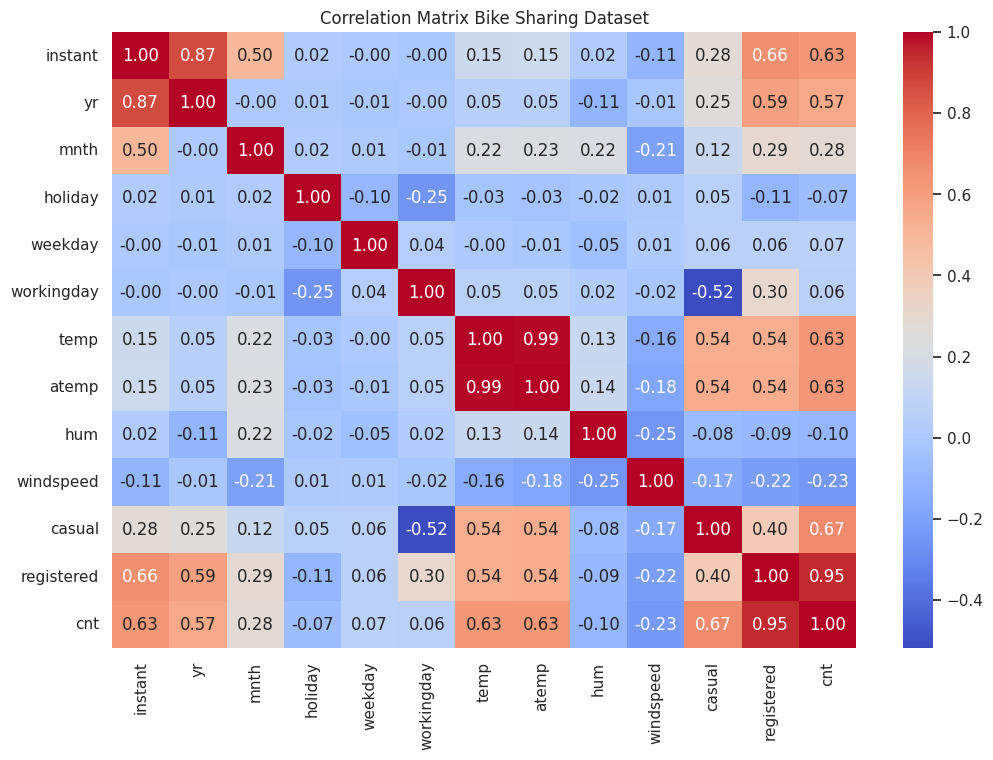

In [24]:
plt.figure(figsize=(12,8))

correlation_matrix = day_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix Bike Sharing Dataset')
plt.show()

**Insight:** (Opsional)
- Variabel temperature (`temp`) memiliki korelasi positif yang cukup kuat terhadap jumlah rental (`cnt`).
- Variabel humidity (`hum`) memiliki korelasi negatif terhadap jumlah rental.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca cerah menghasilkan rata-rata rental tertinggi yaitu sekitar 4876 rental per hari, sedangkan kondisi hujan lebat menghasilkan rata-rata rental terendah. Hal ini menunjukkan bahwa cuaca memiliki pengaruh signifikan terhadap aktivitas penyewaan sepeda.
- **Conclusion pertanyaan 2:** Puncak penyewaan sepeda pada hari kerja terjadi pada pukul 08.00 dan 17.00, yang menunjukkan pola commuting pengguna saat berangkat dan pulang kerja.
- ...

**Rekomendasi Action Item:**
- Menambah jumlah sepeda dan staf operasional pada jam sibuk hari kerja.
- Menyiapkan promosi khusus saat cuaca kurang baik untuk menjaga jumlah penyewaan.
- Mengoptimalkan maintenance sepeda pada jam dengan penyewaan rendah.
- Membuat sistem prediksi permintaan berdasarkan cuaca dan waktu.